# Naive Generative Model — Swiss Roll Distribution



## 1. Imports & Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Swiss Roll Dataset

The Swiss Roll is a classic 2D dataset with a spiral structure

In [3]:
def swissRoll(samples=1024, noise=0.5):
    """Generate a 2D Swiss Roll distribution (from the lecture slides)."""
    t = 1.5 * 3.14 * (1 + 2 * tf.random.uniform((samples, 1)))
    x = t * tf.math.cos(t)
    y = t * tf.math.sin(t)
    X = tf.concat([x, y], axis=1)
    if noise > 0:
        X += noise * tf.random.normal(shape=(samples, 2))
    return X


# Generate a large sample to visualise the target distribution
target_samples = swissRoll(samples=4096, noise=0.5).numpy()



## 3. Source Distribution

The source distribution is a **standard 2D Gaussian** $\mathcal{N}(0, I)$.

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_42591/958915654.py:11: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('Source Distribution — $\mathcal{N}(0, I)$', fontsize=13)


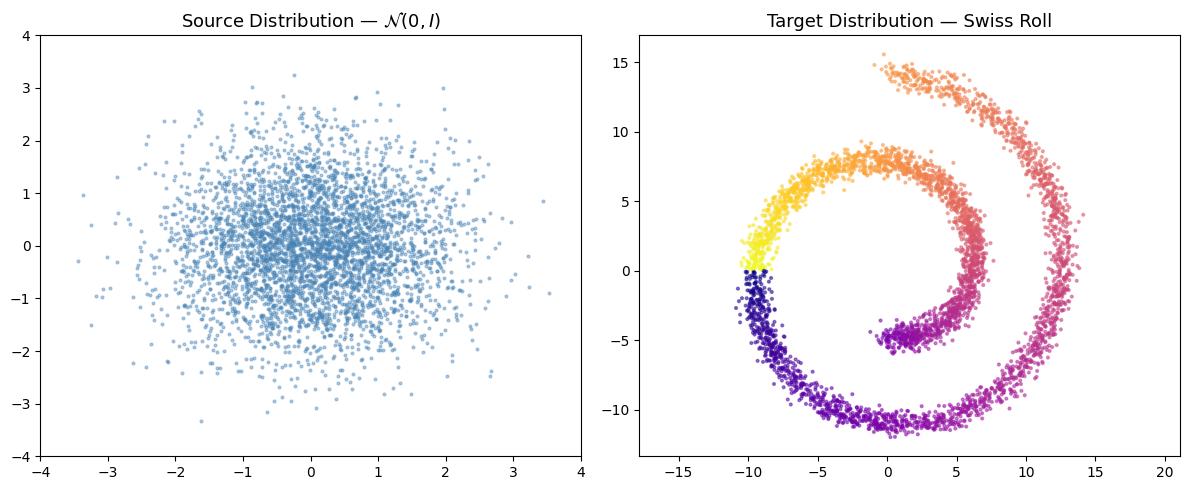

In [4]:
def sample_source(batch_size=1024):
    """Sample from a standard 2D Gaussian (source distribution)."""
    return tf.random.normal(shape=(batch_size, 2))


source_samples = sample_source(4096).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(source_samples[:, 0], source_samples[:, 1],
                s=4, alpha=0.4, color='steelblue')
axes[0].set_title('Source Distribution — $\mathcal{N}(0, I)$', fontsize=13)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)

axes[1].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.5, c=np.arctan2(target_samples[:, 1], target_samples[:, 0]),
                cmap='plasma')
axes[1].set_title('Target Distribution — Swiss Roll', fontsize=13)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

## 4. Naive Model Architecture


```
2 → Dense(64) → BatchNorm → ReLU → ... (4 blocks) → 2
```

- Input: 2D source sample
- Output: 2D predicted target point
- Loss: **MSE**
- ~16k parameters

In [5]:
def build_naive_model(hidden_dim=64, n_blocks=4):
    """Naive generative model: Dense → BatchNorm → ReLU blocks."""
    inputs = keras.Input(shape=(2,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    outputs = layers.Dense(2)(x)   # linear output — raw 2D coordinates
    return keras.Model(inputs, outputs, name='naive_model')


model = build_naive_model()
model.summary()

Model: "naive_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,826 (54.01 KB)

 Trainable params: 13,314 (52.01 KB)

 Non-trainable params: 512 (2.00 KB)

## 5. Training Loop

Hyperparameters
- Batch size: **1024**
- Steps: **1000**
- Optimizer: **Adam** with lr = 1e-3

### What my loop do
1. Sample a point from the target distribution
2. Sample a point from the source distribution
3. Feed the source point to the model
4. Compare model output to the target point using MSE
5. Update parameters



In [6]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
mse_loss  = keras.losses.MeanSquaredError()

BATCH_SIZE = 1024
STEPS      = 1000

loss_history = []

for step in range(STEPS):
    # --- Step 1 & 2: sample from both distributions ---
    target = swissRoll(samples=BATCH_SIZE, noise=0.5)          # target samples
    source = sample_source(BATCH_SIZE)                          # source samples (model input)

    # --- Steps 3-5: forward pass, loss, update ---
    with tf.GradientTape() as tape:
        prediction = model(source, training=True)
        loss = mse_loss(target, prediction)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(loss.numpy())

    if step % 100 == 0:
        print(f'Step {step:4d} / {STEPS}  |  MSE Loss: {loss.numpy():.4f}')

print('\nTraining complete!')

Step    0 / 1000  |  MSE Loss: 48.5429
Step  100 / 1000  |  MSE Loss: 47.8757
Step  200 / 1000  |  MSE Loss: 47.7261
Step  300 / 1000  |  MSE Loss: 45.5791
Step  400 / 1000  |  MSE Loss: 46.2868
Step  500 / 1000  |  MSE Loss: 45.2862
Step  600 / 1000  |  MSE Loss: 46.1873
Step  700 / 1000  |  MSE Loss: 46.4796
Step  800 / 1000  |  MSE Loss: 44.5504
Step  900 / 1000  |  MSE Loss: 47.9370

Training complete!


## 6. Training Curve

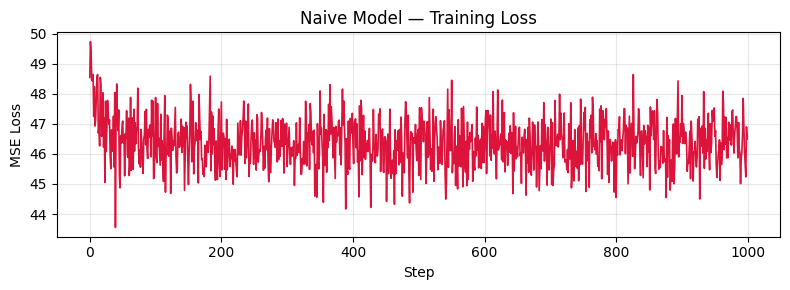

In [7]:
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='crimson', linewidth=1.2)
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.title('Naive Model — Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Generated Samples vs. Target Distribution

now generate samples by feeding fresh Gaussian noise into the model and observe what it produces.

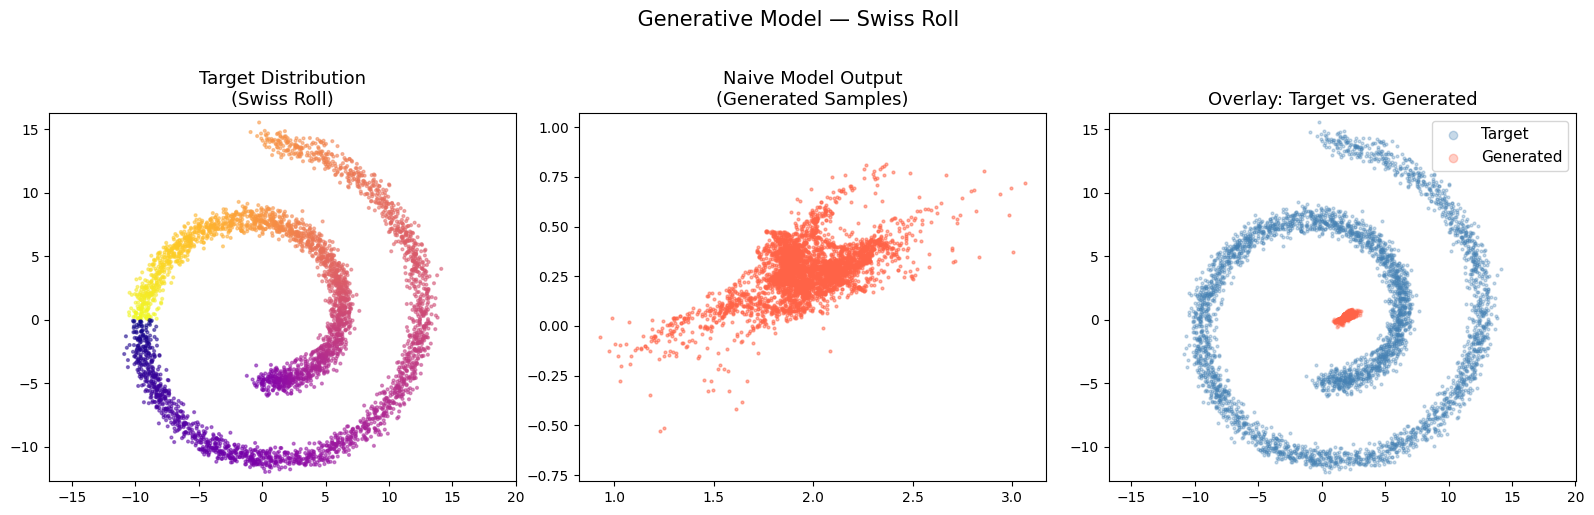

In [8]:
N_GEN = 4096
z = sample_source(N_GEN)                        # fresh source samples
generated = model(z, training=False).numpy()    # model predictions

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground-truth target
axes[0].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.5,
                c=np.arctan2(target_samples[:, 1], target_samples[:, 0]),
                cmap='plasma')
axes[0].set_title('Target Distribution\n(Swiss Roll)', fontsize=13)
axes[0].axis('equal')

# Generated samples
axes[1].scatter(generated[:, 0], generated[:, 1],
                s=4, alpha=0.5, color='tomato')
axes[1].set_title('Naive Model Output\n(Generated Samples)', fontsize=13)
axes[1].axis('equal')

# Overlay for comparison
axes[2].scatter(target_samples[:N_GEN, 0], target_samples[:N_GEN, 1],
                s=4, alpha=0.3, color='steelblue', label='Target')
axes[2].scatter(generated[:, 0], generated[:, 1],
                s=4, alpha=0.3, color='tomato', label='Generated')
axes[2].set_title('Overlay: Target vs. Generated', fontsize=13)
axes[2].axis('equal')
axes[2].legend(markerscale=3, fontsize=11)

plt.suptitle(' Generative Model — Swiss Roll', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 8. Analysis — Why Does the Naive Approach Fail?

the naive model collapses to predicting the mean of the distribution.

In [9]:
target_mean = target_samples.mean(axis=0)
generated_mean = generated.mean(axis=0)
generated_std  = generated.std(axis=0)

print('=== Distribution Statistics ===')
print(f'Target mean:       ({target_mean[0]:.3f}, {target_mean[1]:.3f})')
print(f'Generated mean:    ({generated_mean[0]:.3f}, {generated_mean[1]:.3f})')
print(f'Generated std:     ({generated_std[0]:.3f}, {generated_std[1]:.3f})')
print(f'Target std:        ({target_samples.std(axis=0)[0]:.3f}, {target_samples.std(axis=0)[1]:.3f})')
print()



=== Distribution Statistics ===
Target mean:       (1.970, 0.187)
Generated mean:    (1.965, 0.277)
Generated std:     (0.229, 0.138)
Target std:        (6.726, 6.887)



## 9. Summary

| Aspect | Observation |
|--------|-------------|
| **Training loss** | Converges steadily — the model *is* learning something |
| **Generated distribution** | Collapses to a blob near the mean of the Swiss Roll |
| **Root cause** | MSE with unknown target sample → model minimises expected squared error = **predicts the mean** |

### Why this happens

The model receives a source Gaussian sample as input but is compared against a randomly drawn target sample. Since the source and target are sampled independently, the optimal MSE prediction for any input $z$ is:

$$\hat{x}^* = \mathbb{E}[x_{\text{target}}] = \text{mean of Swiss Roll} \approx (0, 0)$$

### What should we do?
VAEs and Reparametrize so the problem becomes well-posed and MSE can be used correctly.


#10. VAE

In [10]:
LATENT_DIM = 2   # same dimensionality as input for easy visualisation

# ── Encoder ──────────────────────────────────────────────────────────────────
def build_encoder(input_dim=2, latent_dim=LATENT_DIM, hidden_dim=64, n_blocks=4):
    """Maps x → (mean, log_var) of q(z|x)."""
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    # Output size is 2×latent_dim: first half = mean, second half = log_var
    latent = layers.Dense(latent_dim * 2)(x)
    return keras.Model(inputs, latent, name='encoder')


# ── Decoder ──────────────────────────────────────────────────────────────────
def build_decoder(latent_dim=LATENT_DIM, output_dim=2, hidden_dim=64, n_blocks=4):
    """Maps z → x̂ (reconstruction of input)."""
    inputs = keras.Input(shape=(latent_dim,))
    x = inputs
    for _ in range(n_blocks):
        x = layers.Dense(hidden_dim)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    outputs = layers.Dense(output_dim)(x)
    return keras.Model(inputs, outputs, name='decoder')


encoder = build_encoder()
decoder = build_decoder()

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,956 (54.52 KB)

 Trainable params: 13,444 (52.52 KB)

 Non-trainable params: 512 (2.00 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,826 (54.01 KB)

 Trainable params: 13,314 (52.01 KB)

 Non-trainable params: 512 (2.00 KB)

In [11]:
def reparametrize(mean, log_var):
    """z = mean + std * epsilon,  epsilon ~ N(0,I)"""
    std = tf.exp(0.5 * log_var)
    epsilon = tf.random.normal(shape=tf.shape(mean))
    return mean + std * epsilon


def kl_divergence(mean, log_var):
    """
    KL( N(mean, std²) || N(0,1) ) per-sample, averaged over batch.
    Closed-form: 0.5 * sum(mean² + exp(log_var) - log_var - 1)
    """
    kl = 0.5 * tf.reduce_sum(
        tf.square(mean) + tf.exp(log_var) - log_var - 1.0,
        axis=1
    )
    return tf.reduce_mean(kl)


def vae_forward(x, training=True):
    latent = encoder(x, training=training)                  # → [B, 2*latent_dim]
    mean    = latent[:, :LATENT_DIM]
    log_var = latent[:, LATENT_DIM:]
    z       = reparametrize(mean, log_var)                  # reparametrization trick
    x_hat   = decoder(z, training=training)                 # reconstruction
    return x_hat, mean, log_var

print('VAE building blocks ready.')

VAE building blocks ready.


In [12]:
optimizer_vae = keras.optimizers.Adam(learning_rate=1e-3)

BETA = 0.1      # weight of KL term (β-VAE style; 1.0 is standard VAE)
BATCH_SIZE = 1024
STEPS = 1000

vae_total_history = []
vae_recon_history = []
vae_kl_history    = []

all_params = encoder.trainable_variables + decoder.trainable_variables

for step in range(STEPS):
    # For the VAE the INPUT and TARGET are the SAME — this is what makes it well-posed!
    x_batch = swissRoll(samples=BATCH_SIZE, noise=0.5)

    with tf.GradientTape() as tape:
        x_hat, mean, log_var = vae_forward(x_batch, training=True)

        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x_batch - x_hat), axis=1))
        kl_loss    = kl_divergence(mean, log_var)
        total_loss = recon_loss + BETA * kl_loss

    grads = tape.gradient(total_loss, all_params)
    optimizer_vae.apply_gradients(zip(grads, all_params))

    vae_total_history.append(total_loss.numpy())
    vae_recon_history.append(recon_loss.numpy())
    vae_kl_history.append(kl_loss.numpy())

    if step % 200 == 0:
        print(f'Step {step:4d}/{STEPS}  |  Total: {total_loss.numpy():.3f}  '
              f'Recon: {recon_loss.numpy():.3f}  KL: {kl_loss.numpy():.3f}')

print('VAE training complete!')

Step    0/1000  |  Total: 101.894  Recon: 101.732  KL: 1.617
Step  200/1000  |  Total: 1.566  Recon: 0.769  KL: 7.971
Step  400/1000  |  Total: 1.177  Recon: 0.526  KL: 6.510
Step  600/1000  |  Total: 1.161  Recon: 0.535  KL: 6.257
Step  800/1000  |  Total: 1.058  Recon: 0.425  KL: 6.324
VAE training complete!


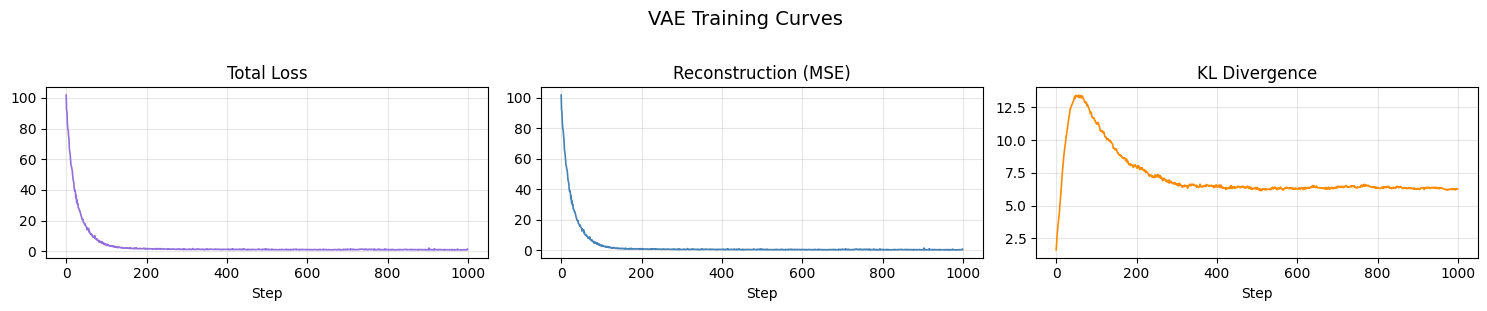

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, hist, label, color in zip(
        axes,
        [vae_total_history, vae_recon_history, vae_kl_history],
        ['Total Loss', 'Reconstruction (MSE)', 'KL Divergence'],
        ['mediumpurple', 'steelblue', 'darkorange']):
    ax.plot(hist, color=color, linewidth=1.2)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Step')
    ax.grid(alpha=0.3)
plt.suptitle('VAE Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#11. LATENT(Z) Space visualization

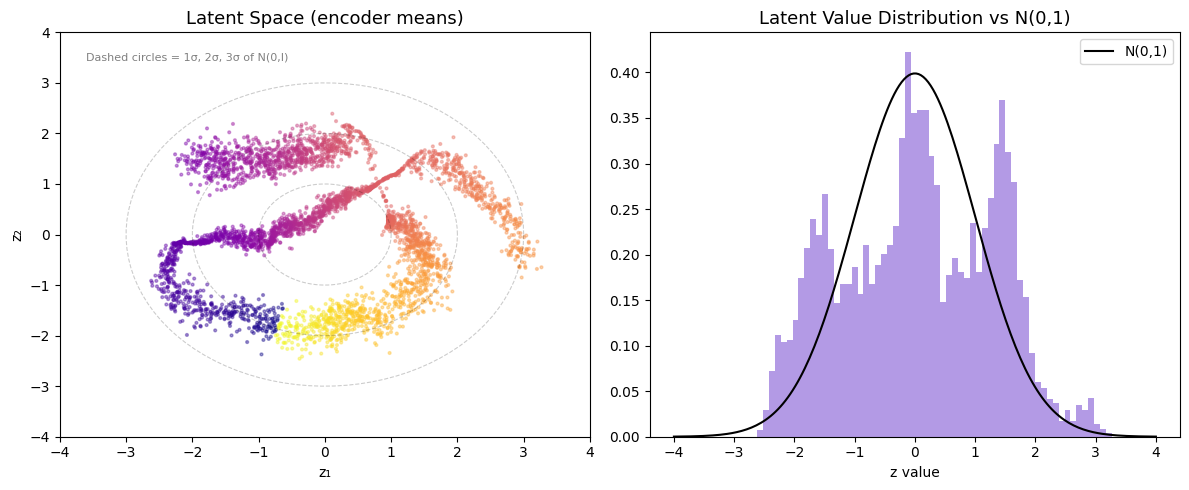

In [14]:
# Encode 4096 Swiss Roll samples to inspect the latent space
x_vis = swissRoll(samples=4096, noise=0.5)
latent_vis = encoder(x_vis, training=False).numpy()
means_vis   = latent_vis[:, :LATENT_DIM]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(means_vis[:, 0], means_vis[:, 1],
                s=4, alpha=0.4,
                c=np.arctan2(x_vis.numpy()[:, 1], x_vis.numpy()[:, 0]),
                cmap='plasma')
axes[0].set_title('Latent Space (encoder means)', fontsize=13)
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)

# Overlay a reference N(0,I) contour
theta = np.linspace(0, 2*np.pi, 100)
for r in [1, 2, 3]:
    axes[0].plot(r*np.cos(theta), r*np.sin(theta), 'k--', alpha=0.2, linewidth=0.8)
axes[0].text(0.05, 0.95, 'Dashed circles = 1σ, 2σ, 3σ of N(0,I)',
             transform=axes[0].transAxes, fontsize=8, va='top', color='gray')

# Histogram of latent values
axes[1].hist(means_vis.flatten(), bins=60, color='mediumpurple', alpha=0.7, density=True)
z_range = np.linspace(-4, 4, 200)
axes[1].plot(z_range, np.exp(-0.5*z_range**2)/np.sqrt(2*np.pi), 'k-', linewidth=1.5, label='N(0,1)')
axes[1].set_title('Latent Value Distribution vs N(0,1)', fontsize=13)
axes[1].legend()
axes[1].set_xlabel('z value')

plt.tight_layout()
plt.show()

#12. discard encoder, use only decoder

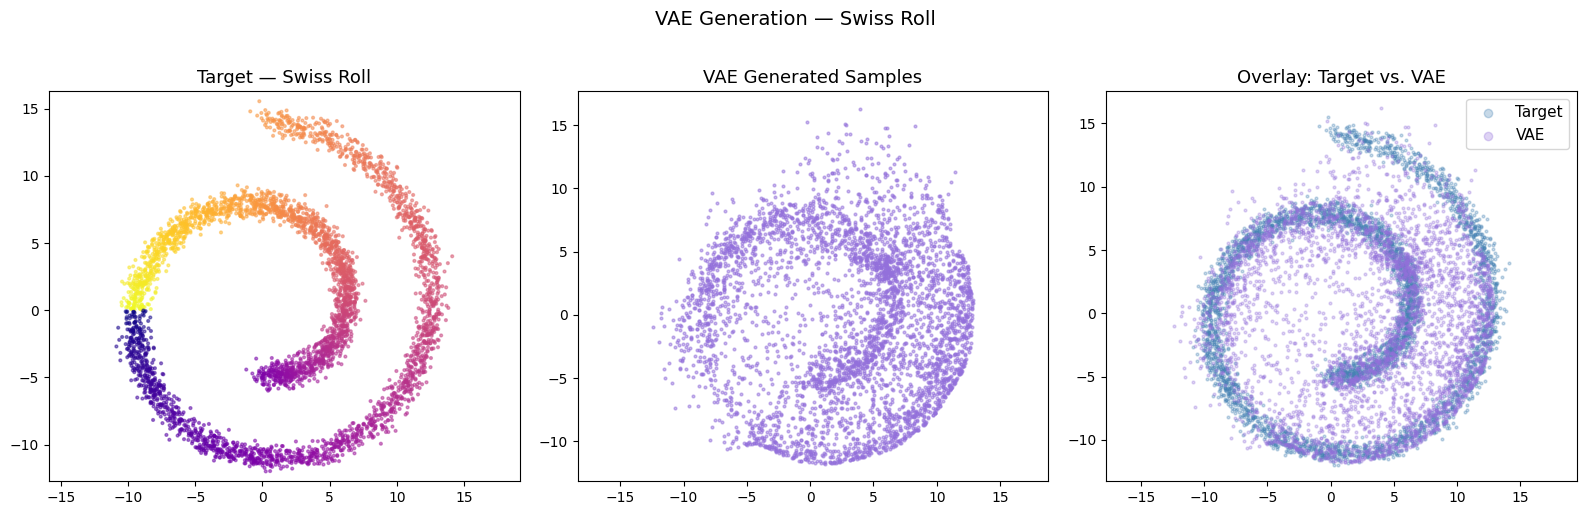

Target std:      [6.726 6.887]
VAE gen std:     [6.048 6.011]


In [15]:
N_GEN = 4096
z_sample = tf.random.normal(shape=(N_GEN, LATENT_DIM))   # sample from prior
vae_generated = decoder(z_sample, training=False).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.5, c=np.arctan2(target_samples[:, 1], target_samples[:, 0]), cmap='plasma')
axes[0].set_title('Target — Swiss Roll', fontsize=13)
axes[0].axis('equal')

axes[1].scatter(vae_generated[:, 0], vae_generated[:, 1],
                s=4, alpha=0.5, color='mediumpurple')
axes[1].set_title('VAE Generated Samples', fontsize=13)
axes[1].axis('equal')

axes[2].scatter(target_samples[:, 0], target_samples[:, 1],
                s=4, alpha=0.3, color='steelblue', label='Target')
axes[2].scatter(vae_generated[:, 0], vae_generated[:, 1],
                s=4, alpha=0.3, color='mediumpurple', label='VAE')
axes[2].set_title('Overlay: Target vs. VAE', fontsize=13)
axes[2].axis('equal')
axes[2].legend(markerscale=3, fontsize=11)

plt.suptitle('VAE Generation — Swiss Roll', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Target std:      {target_samples.std(axis=0).round(3)}')
print(f'VAE gen std:     {vae_generated.std(axis=0).round(3)}')